In [13]:
# Cell 1: Imports and Global Configuration
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, accuracy_score, f1_score, average_precision_score
from sklearn.preprocessing import LabelEncoder
from catboost import CatBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import joblib

# Set display options for better visibility
pd.set_option('display.max_columns', None)

# Define the target we are optimizing for today
TARGET_COL = 'target_3m_call'
DATA_PATH = 'data/training_data_4.csv'

print("✅ Environment Ready. Optimized for Precision & F1.")

✅ Environment Ready. Optimized for Precision & F1.


In [14]:
# Cell 2: Loading and Encoding the Textbook
print(f"⏳ Loading {DATA_PATH}...")
df = pd.read_csv(DATA_PATH)

# 1. Ensure time is datetime and UTC
if 'time' not in df.columns:
    df.rename(columns={df.columns[0]: 'time'}, inplace=True)
df['time'] = pd.to_datetime(df['time']).dt.tz_convert('UTC')

# 2. Encode Asset ID (Required for XGBoost/LightGBM)
le = LabelEncoder()
df['asset_id'] = le.fit_transform(df['asset_id'].astype(str))

# 3. Identify Columns
drop_cols = ['time', '<OPEN>', '<HIGH>', '<LOW>', '<CLOSE>', '<TICKVOL>', '<SPREAD>', '<VOL>', 
             'target_1m_call', 'target_1m_put', 'target_2m_call', 'target_2m_put',
             'target_3m_call', 'target_3m_put', 'target_4m_call', 'target_4m_put',
             'target_5m_call', 'target_5m_put']

feature_cols = [c for c in df.columns if c not in drop_cols]

print(f"✅ Data Loaded: {len(df):,} rows.")
print(f"✅ Features Identified: {len(feature_cols)}")
print(f"✅ Asset Mapping: {dict(zip(le.classes_, range(len(le.classes_))))}")

⏳ Loading data/training_data_4.csv...
✅ Data Loaded: 992,727 rows.
✅ Features Identified: 123
✅ Asset Mapping: {'AUDJPY': 0, 'EURGBP': 1, 'EURUSD': 2, 'GBPUSD': 3}


In [15]:
# Cell 3: Time-Based Splitting and Imbalance Calculation
split_date = pd.Timestamp("2025-10-01").tz_localize('UTC')

# Create Train and Validation Sets
train_df = df[df['time'] < split_date].copy()
val_df = df[df['time'] >= split_date].copy()

X_train = train_df[feature_cols]
y_train = train_df[TARGET_COL]
X_val = val_df[feature_cols]
y_val = val_df[TARGET_COL]

# --- IMBALANCE SHIELD ---
neg_count = sum(y_train == 0)
pos_count = sum(y_train == 1)
# The ratio of losses to wins (e.g., 67 / 33 = ~2.03)
pos_weight = neg_count / pos_count

print(f"✂️  Split Complete at {split_date}")
print(f"    -> Training Rows:   {len(X_train):,}")
print(f"    -> Validation Rows: {len(X_val):,}")
print(f"    -> Imbalance Ratio: {pos_weight:.2f}")
print("-" * 30)
print(f"🚀 SCALE WEIGHT: {pos_weight:.2f} (Model will prioritize wins by this factor)")

✂️  Split Complete at 2025-10-01 00:00:00+00:00
    -> Training Rows:   831,864
    -> Validation Rows: 160,863
    -> Imbalance Ratio: 2.05
------------------------------
🚀 SCALE WEIGHT: 2.05 (Model will prioritize wins by this factor)


In [16]:
# Cell 4: Reusable Evaluation Function
def display_billionaire_dashboard(model_name, y_true, y_probs):
    """
    Calculates Precision (Actual Win Rate) at various confidence levels.
    Precision = Total Wins / Total Trades Taken.
    """
    print(f"\n🏆 {model_name.upper()} BILLIONAIRE DASHBOARD")
    print("-" * 40)
    print(f"{'Confidence':<15} | {'Win Rate':<10} | {'Trades':<10}")
    print("-" * 40)
    
    for threshold in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85]:
        # Identify trades that meet the threshold
        mask = y_probs > threshold
        trade_count = np.sum(mask)
        
        if trade_count > 0:
            # Calculate win rate for these specific trades
            # Since target is 1 (Win), the mean is the win rate
            win_rate = np.mean(y_true[mask])
            print(f">{int(threshold*100)}% sure      | {win_rate:.4f}     | {trade_count:,}")
        else:
            print(f">{int(threshold*100)}% sure      | No Trades  | 0")
    print("-" * 40)

print("✅ Evaluation Function Defined.")

✅ Evaluation Function Defined.


In [17]:
import time

# Cell 5: Training CatBoost
print("🔥 Forging CatBoost Brain...")

cat_model = CatBoostClassifier(
    iterations=2000, 
    learning_rate=0.03, 
    depth=8, 
    loss_function='Logloss',
    eval_metric='Precision',  # Optimization target is now Win Rate
    scale_pos_weight=pos_weight,  # THE IMBALANCE SHIELD
    early_stopping_rounds=100,
    verbose=100,
    task_type="CPU"
)

# Start the timer
start_time = time.time()

cat_model.fit(X_train, y_train, eval_set=(X_val, y_val))

# Stop the timer
end_time = time.time()
elapsed_time = end_time - start_time

print(f"⏱ CatBoost training completed in {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes).")

# Get probabilities for the dashboard
cat_probs = cat_model.predict_proba(X_val)[:, 1]

# Display Dashboard
display_billionaire_dashboard("CatBoost V2 (Balanced)", y_val, cat_probs)


🔥 Forging CatBoost Brain...
0:	learn: 0.5202582	test: 0.5117608	best: 0.5117608 (0)	total: 568ms	remaining: 18m 55s
100:	learn: 0.5326873	test: 0.5219592	best: 0.5226011 (87)	total: 44.8s	remaining: 14m 2s
200:	learn: 0.5391853	test: 0.5223171	best: 0.5231740 (157)	total: 1m 35s	remaining: 14m 11s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.5231739785
bestIteration = 157

Shrink model to first 158 iterations.
⏱ CatBoost training completed in 125.13 seconds (2.09 minutes).

🏆 CATBOOST V2 (BALANCED) BILLIONAIRE DASHBOARD
----------------------------------------
Confidence      | Win Rate   | Trades    
----------------------------------------
>50% sure      | 0.3485     | 89,958
>55% sure      | 0.4322     | 3,376
>60% sure      | 0.5442     | 792
>65% sure      | 0.6840     | 269
>70% sure      | 0.8280     | 93
>75% sure      | 0.8966     | 29
>80% sure      | 1.0000     | 3
>85% sure      | No Trades  | 0
----------------------------------------


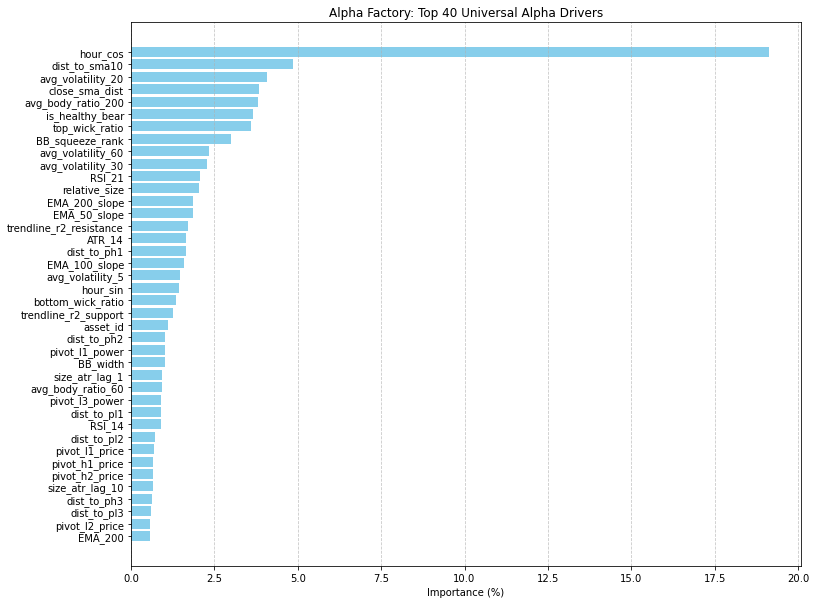


RANK  | FEATURE NAME                        | IMPORTANCE (%) 
1     | hour_cos                            | 19.117701
2     | dist_to_sma10                       | 4.843478
3     | avg_volatility_20                   | 4.082614
4     | close_sma_dist                      | 3.841578
5     | avg_body_ratio_200                  | 3.801302
6     | is_healthy_bear                     | 3.670529
7     | top_wick_ratio                      | 3.590766
8     | BB_squeeze_rank                     | 2.986346
9     | avg_volatility_60                   | 2.354520
10    | avg_volatility_30                   | 2.286903
11    | RSI_21                              | 2.070786
12    | relative_size                       | 2.053878
13    | EMA_200_slope                       | 1.867763
14    | EMA_50_slope                        | 1.867464
15    | trendline_r2_resistance             | 1.721994
16    | ATR_14                              | 1.642303
17    | dist_to_ph1                         | 1.638660
1

In [ ]:
# Cell 10: High-Precision Feature Audit
def run_feature_audit(model, feature_names):
    # 1. Extract and Sort Importance
    importance = model.get_feature_importance()
    fi_df = pd.DataFrame({'feature': feature_names, 'importance': importance})
    fi_df = fi_df.sort_values(by='importance', ascending=False)

    # 2. Plot TOP 40 ALPHA DRIVERS (Visual Audit)
    plt.figure(figsize=(12, 10))
    top_40 = fi_df.head(40)
    plt.barh(top_40['feature'], top_40['importance'], color='skyblue')
    plt.gca().invert_yaxis()
    plt.title('Alpha Factory: Top 40 Universal Alpha Drivers')
    plt.xlabel('Importance (%)')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

    # 3. TEXT OUTPUT: TOP 40 ALPHA DRIVERS (Copiable)
    print("\n" + "="*60)
    print(f"{'RANK':<5} | {'FEATURE NAME':<35} | {'IMPORTANCE (%)':<15}")
    print("="*60)
    for i, row in enumerate(top_40.itertuples(), 1):
        print(f"{i:<5} | {row.feature:<35} | {row.importance:.6f}")
    print("="*60)

    # 4. TEXT OUTPUT: THE PURGE LIST (Below 0.01% - Copiable)
    purge_list = fi_df[fi_df['importance'] < 0.01]
    
    print("\n" + "="*60)
    print("🗑️  THE PURGE LIST: FEATURES WITH ZERO/MINIMAL IMPACT (<0.01%)")
    print("="*60)
    if not purge_list.empty:
        print(f"{'COUNT':<5} | {'FEATURE NAME':<35} | {'IMPORTANCE (%)':<15}")
        print("-" * 60)
        for i, row in enumerate(purge_list.itertuples(), 1):
            print(f"{i:<5} | {row.feature:<35} | {row.importance:.6f}")
    else:
        print("No zero-impact features found. Every column is contributing.")
    print("="*60)
    
    # 5. Save Top 40 for V3 Interaction Engineering
    top_40_list = top_40['feature'].tolist()
    joblib.dump(top_40_list, 'models/universal_top_40_features.joblib')
    print(f"\n✅ Saved {len(top_40_list)} features to models/universal_top_40_features.joblib")
    
    return top_40_list

# EXECUTE THE AUDIT
# Make sure your cat_model and X_train are defined from the 7M run
top_40_drivers = run_feature_audit(cat_model, X_train.columns)

🔍 Performing Deep Model Audit...

📊 CLASSIFICATION REPORT (0.5 Threshold):
              precision    recall  f1-score   support

           0       0.71      0.46      0.56    109182
           1       0.35      0.61      0.44     51681

    accuracy                           0.51    160863
   macro avg       0.53      0.53      0.50    160863
weighted avg       0.60      0.51      0.52    160863



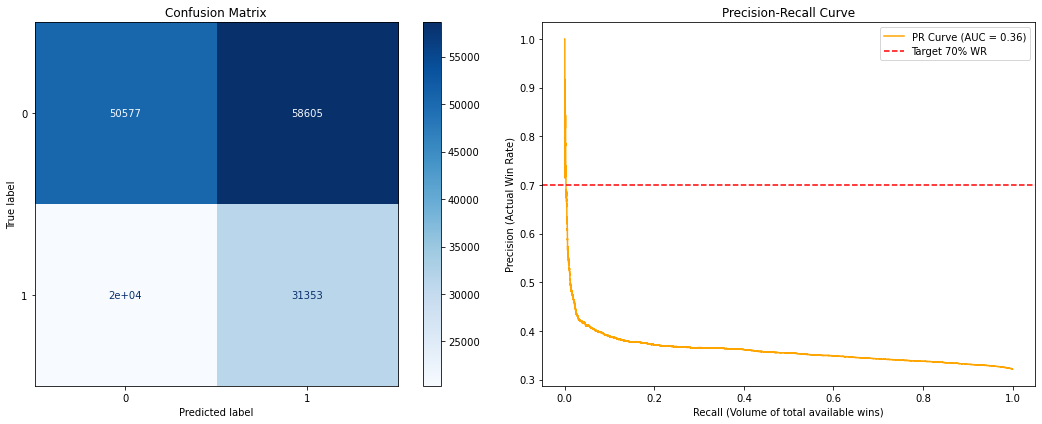


🎯 STRATEGIC TARGETING:
To maintain a 70% Win Rate, set your probability threshold to: 0.6642
This will capture approximately 0.3% of all available winning setups.


In [6]:
# Cell 9: Advanced Model Audit (CatBoost Only)
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, auc

def run_advanced_audit(model, X_val, y_val):
    print("🔍 Performing Deep Model Audit...")
    
    # 1. Get Predictions and Probabilities
    preds = model.predict(X_val)
    probs = model.predict_proba(X_val)[:, 1]
    
    # 2. Classification Report (Raw Stats)
    print("\n📊 CLASSIFICATION REPORT (0.5 Threshold):")
    print(classification_report(y_val, preds))
    
    # 3. Confusion Matrix (Error Distribution)
    # This shows: How many winners did we miss? How many losers did we take?
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    
    ConfusionMatrixDisplay.from_estimator(model, X_val, y_val, cmap='Blues', ax=ax[0])
    ax[0].set_title("Confusion Matrix")
    
    # 4. Precision-Recall Curve (The Strategic Lever)
    precision, recall, thresholds = precision_recall_curve(y_val, probs)
    pr_auc = auc(recall, precision)
    
    ax[1].plot(recall, precision, color='orange', label=f'PR Curve (AUC = {pr_auc:.2f})')
    ax[1].set_xlabel('Recall (Volume of total available wins)')
    ax[1].set_ylabel('Precision (Actual Win Rate)')
    ax[1].set_title('Precision-Recall Curve')
    ax[1].axhline(y=0.70, color='red', linestyle='--', label='Target 70% WR')
    ax[1].legend()
    
    plt.tight_layout()
    plt.show()
    
    # 5. Finding the 'Billionaire Cutoff'
    # We find the threshold that gives us the highest volume while staying above 70% Precision
    target_precision = 0.70
    idx = np.where(precision >= target_precision)[0][0]
    best_threshold = thresholds[idx]
    
    print(f"\n🎯 STRATEGIC TARGETING:")
    print(f"To maintain a 70% Win Rate, set your probability threshold to: {best_threshold:.4f}")
    print(f"This will capture approximately {recall[idx]*100:.1f}% of all available winning setups.")

# EXECUTE THE AUDIT
run_advanced_audit(cat_model, X_val, y_val)

In [7]:
fjaiofjanivnasio

NameError: name 'fjaiofjanivnasio' is not defined

In [ ]:
# Cell 6: Training XGBoost
print("🔥 Forging XGBoost Brain...")

# XGBoost requires the scale_pos_weight explicitly
xgb_model = XGBClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=8,
    objective='binary:logistic',
    scale_pos_weight=pos_weight, # THE IMBALANCE SHIELD
    tree_method='hist', # Faster training
    early_stopping_rounds=100,
    eval_metric=['logloss', 'aucpr'] # Optimize for Precision-Recall Area
)

# Train the model
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

# Get probabilities
xgb_probs = xgb_model.predict_proba(X_val)[:, 1]

# Display Dashboard
display_billionaire_dashboard("XGBoost V2 (Balanced)", y_val, xgb_probs)

🔥 Forging XGBoost Brain...
[0]	validation_0-logloss:0.69287	validation_0-aucpr:0.34847
[100]	validation_0-logloss:0.68765	validation_0-aucpr:0.35944
[199]	validation_0-logloss:0.68643	validation_0-aucpr:0.35937

🏆 XGBOOST V2 (BALANCED) BILLIONAIRE DASHBOARD
----------------------------------------
Confidence      | Win Rate   | Trades    
----------------------------------------
>50% sure      | 0.3477     | 86,758
>55% sure      | 0.4268     | 4,016
>60% sure      | 0.5359     | 1,004
>65% sure      | 0.6269     | 394
>70% sure      | 0.7078     | 154
>75% sure      | 0.8148     | 54
>80% sure      | 0.8462     | 13
>85% sure      | 1.0000     | 3
----------------------------------------


In [ ]:
# Cell 7: Training LightGBM
print("🔥 Forging LightGBM Brain...")

# LightGBM handles imbalance with scale_pos_weight
lgbm_model = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.03,
    num_leaves=64, # Important for LGBM's complexity
    max_depth=8,
    objective='binary',
    scale_pos_weight=pos_weight, # THE IMBALANCE SHIELD
    metric='auc', # Optimize for Area Under the Curve
    early_stopping_round=100,
    importance_type='gain', # Measure importance by profit contribution
    verbosity=-1
)

lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)]
)

# Get probabilities
lgbm_probs = lgbm_model.predict_proba(X_val)[:, 1]

# Display Dashboard
display_billionaire_dashboard("LightGBM V2 (Balanced)", y_val, lgbm_probs)

🔥 Forging LightGBM Brain...

🏆 LIGHTGBM V2 (BALANCED) BILLIONAIRE DASHBOARD
----------------------------------------
Confidence      | Win Rate   | Trades    
----------------------------------------
>50% sure      | 0.3548     | 68,689
>55% sure      | 0.4448     | 2,736
>60% sure      | 0.5498     | 853
>65% sure      | 0.6307     | 371
>70% sure      | 0.7174     | 138
>75% sure      | 0.8824     | 34
>80% sure      | 0.7500     | 4
>85% sure      | No Trades  | 0
----------------------------------------


In [ ]:
# Cell 8: The Master Ensemble
print("🧬 Creating the Alpha Ensemble (Committee of 3)...")

# 1. Simple Average Ensemble
# We combine the probabilities we already calculated in the previous cells
ensemble_probs = (cat_probs + xgb_probs + lgbm_probs) / 3

# 2. Weighted Average Ensemble (Giving 50% power to our most 'Honest' model: CatBoost)
# Logic: (0.5 * CatBoost) + (0.25 * XGBoost) + (0.25 * LightGBM)
weighted_ensemble_probs = (0.50 * cat_probs) + (0.25 * xgb_probs) + (0.25 * lgbm_probs)

# Display Dashboard for the Simple Ensemble
display_billionaire_dashboard("Simple Mean Ensemble", y_val, ensemble_probs)

# Display Dashboard for the Weighted Ensemble
display_billionaire_dashboard("Weighted Sniper Ensemble", y_val, weighted_ensemble_probs)

🧬 Creating the Alpha Ensemble (Committee of 3)...

🏆 SIMPLE MEAN ENSEMBLE BILLIONAIRE DASHBOARD
----------------------------------------
Confidence      | Win Rate   | Trades    
----------------------------------------
>50% sure      | 0.3508     | 81,953
>55% sure      | 0.4525     | 2,924
>60% sure      | 0.5545     | 817
>65% sure      | 0.6281     | 320
>70% sure      | 0.7736     | 106
>75% sure      | 0.9091     | 33
>80% sure      | 0.8000     | 5
>85% sure      | No Trades  | 0
----------------------------------------

🏆 WEIGHTED SNIPER ENSEMBLE BILLIONAIRE DASHBOARD
----------------------------------------
Confidence      | Win Rate   | Trades    
----------------------------------------
>50% sure      | 0.3500     | 84,007
>55% sure      | 0.4520     | 2,947
>60% sure      | 0.5574     | 793
>65% sure      | 0.6417     | 307
>70% sure      | 0.7961     | 103
>75% sure      | 0.9333     | 30
>80% sure      | 0.7500     | 4
>85% sure      | No Trades  | 0
---------------------